In [1]:
import numpy as np
import EFC_learningfMRI.globals as gl
from EFC_learningfMRI.util import get_trained_and_untrained, add_flexion_imbalance
from EFC_learningfMRI.vis import plot_im_sess
from EFC_learningfMRI.G_matrix import G_sorted, lme_trained_untrained
from EFC_learningfMRI.pcm import subj_spec_models
import os
import pandas as pd
import PcmPy as pcm
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import seaborn as sb

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


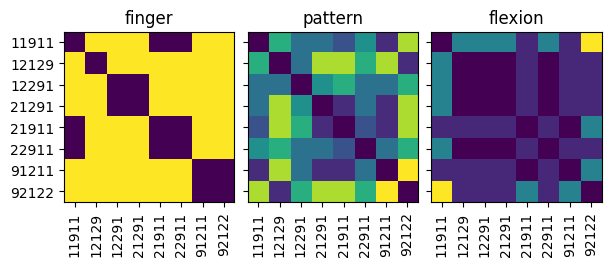

In [2]:
M      = subj_spec_models(order=gl.chordID)
models = ['finger', 'pattern', 'flexion']

fig, axs = plt.subplots(1, len(M), sharex=True, sharey=True, constrained_layout=True, figsize=(6, 4))

for m, Gm in enumerate(M):
    ax = axs[m]
    D  = pcm.G_to_dist(Gm)
    ax.imshow(D)
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(models[m])

plt.show()

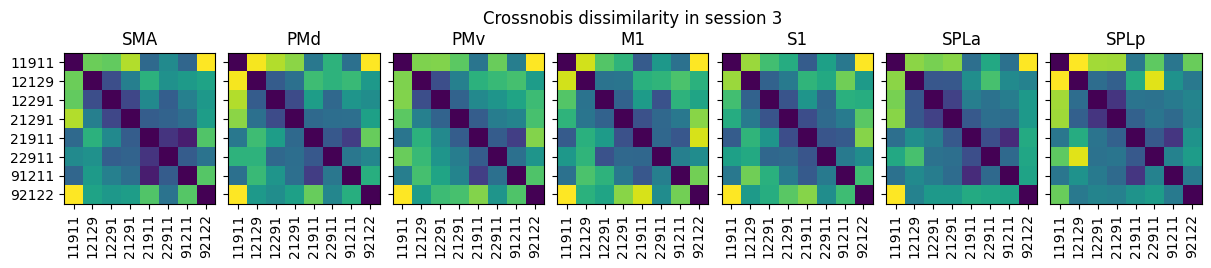

In [3]:
H    = 'L'
rois = gl.rois['ROI']
glm  = 3

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(12, 4))

for r, roi in enumerate(rois):
    ax = axs[r]
    G  = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'G_obs.within_session.3.glm{glm}.{H}.{roi}.npy'))
    G  = G_sorted(G, gl.participants, order=gl.chordID)
    D  = pcm.G_to_dist(G)
    ax.imshow(D.mean(axis=0))
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(f'Crossnobis dissimilarity in session 3\n{roi}' if r==3 else roi)

plt.show()

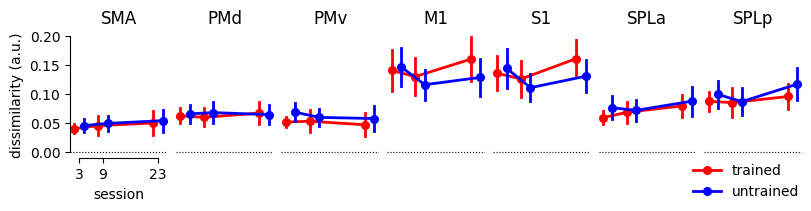

In [4]:
dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
flex_imb = add_flexion_imbalance(dist.pair)
dist['flexion_imbalance'] = flex_imb
dist = dist[dist.Hem=='L']
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('dissimilarity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

plt.show()

     roi  session    ci_low   ci_high         p
1    SMA        3 -0.019075  0.007326  0.383083
10   PMd        3 -0.017030  0.008728  0.527554
19   PMv        3 -0.032693 -0.002122  0.025614
28    M1        3 -0.037734  0.025065  0.692553
37    S1        3 -0.034961  0.018104  0.533533
46  SPLa        3 -0.035561 -0.000522  0.043557
55  SPLp        3 -0.033303  0.005738  0.166410
22   PMv        9 -0.027727  0.013789  0.510548
40    S1        9 -0.006944  0.036502  0.182385
31    M1        9 -0.014879  0.042337  0.346908
13   PMd        9 -0.024550  0.006161  0.240560
4    SMA        9 -0.019257  0.010122  0.542238
49  SPLa        9 -0.020638  0.012001  0.604034
58  SPLp        9 -0.022400  0.015613  0.726393
16   PMd       23 -0.013204  0.016197  0.841854
7    SMA       23 -0.022607  0.012241  0.559869
43    S1       23  0.008078  0.052385  0.007480
34    M1       23  0.001305  0.060987  0.040791
25   PMv       23 -0.028721  0.005724  0.190686
52  SPLa       23 -0.028608  0.009164  0

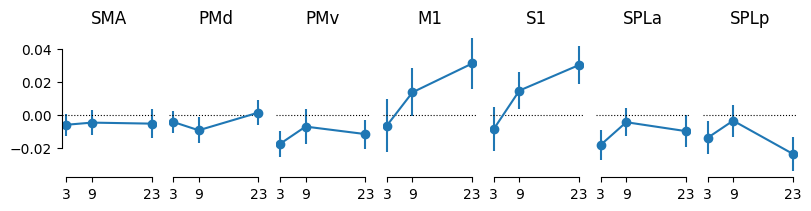

In [5]:
result = lme_trained_untrained(dist)
chord  = result[result.term == 'chord'].sort_values('session')

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

for r, roi in enumerate(rois):
    ax        = axs[r]
    chord_roi = chord[chord.roi==roi]
    ax.errorbar(chord_roi.session, chord_roi.beta, yerr=chord_roi.se, marker='o')
    ax.axhline(0, color='k', lw=.8, ls=':')
    ax.set_title(roi)
    ax.set_xticks(sorted(chord_roi.session.unique()))
    ax.tick_params(left=r==0)

for i, ax in enumerate(axs):sb.despine(ax=ax, trim=True, left=i>0)

print(chord[['roi', 'session', 'ci_low', 'ci_high', 'p']])

plt.show()

In [6]:
rng     = np.random.default_rng(0)
n_perm  = 100                       # lower for a quick look; ~0.3 s per permutation

def shuffle_trained_untrained(df, rng):
    """Give each subject a random 4-of-8 'trained' set and reclassify every pair."""
    df[['a', 'b']] = df.pair.str.split('-', expand=True)
    out            = df.copy()
    for sn, g in df.groupby('sn'):
        tr   = set(rng.choice(np.array(gl.chordID, dtype=str), 4, replace=False))   # this subject's trained chords
        a, b = g.a.isin(tr), g.b.isin(tr)
        out.loc[g.index, 'chord'] = np.where(a & b, 'trained', np.where(~a & ~b, 'untrained', 'trained_untrained'))
    return out

# permutation loop: shuffle labels -> refit -> append
rows = []
for i in range(n_perm):
    dist_perm    = shuffle_trained_untrained(dist, rng)
    res_perm_tmp = lme_trained_untrained(dist_perm)
    rows.append(res_perm_tmp)

result_perm = pd.concat(rows, axis=0)

term, keys = 'chord', ['Hem', 'roi', 'session']

obs  = result.loc[result.term == term, keys + ['beta']].rename(columns={'beta': 'beta_obs'})
perm = result_perm.loc[result_perm.term == term, keys + ['beta']]

p_perm = (perm.merge(obs, on=keys)
              .assign(extreme=lambda d: d.beta.abs() >= d.beta_obs.abs())   # two-sided: |perm| >= |obs|
              .groupby(keys)
              .agg(n=('extreme', 'size'), n_extreme=('extreme', 'sum'))
              .assign(p_perm=lambda d: (1 + d.n_extreme) / (1 + d.n))       # +1 correction
              .reset_index())

              


   Hem   roi  session    n  n_extreme    p_perm
0    L    M1        3  100         80  0.801980
1    L    M1        9  100         60  0.603960
2    L    M1       23  100         13  0.138614
3    L   PMd        3  100         70  0.702970
4    L   PMd        9  100         43  0.435644
5    L   PMd       23  100         89  0.891089
6    L   PMv        3  100         17  0.178218
7    L   PMv        9  100         61  0.613861
8    L   PMv       23  100         39  0.396040
9    L    S1        3  100         68  0.683168
10   L    S1        9  100         35  0.356436
11   L    S1       23  100          5  0.059406
12   L   SMA        3  100         45  0.455446
13   L   SMA        9  100         69  0.693069
14   L   SMA       23  100         71  0.712871
15   L  SPLa        3  100         25  0.257426
16   L  SPLa        9  100         65  0.653465
17   L  SPLa       23  100         62  0.623762
18   L  SPLp        3  100         34  0.346535
19   L  SPLp        9  100         83  0

In [9]:
print(p_perm.sort_values('session'))


   Hem   roi  session    n  n_extreme    p_perm
0    L    M1        3  100         80  0.801980
3    L   PMd        3  100         70  0.702970
6    L   PMv        3  100         17  0.178218
9    L    S1        3  100         68  0.683168
12   L   SMA        3  100         45  0.455446
15   L  SPLa        3  100         25  0.257426
18   L  SPLp        3  100         34  0.346535
7    L   PMv        9  100         61  0.613861
13   L   SMA        9  100         69  0.693069
10   L    S1        9  100         35  0.356436
4    L   PMd        9  100         43  0.435644
1    L    M1        9  100         60  0.603960
16   L  SPLa        9  100         65  0.653465
19   L  SPLp        9  100         83  0.831683
5    L   PMd       23  100         89  0.891089
2    L    M1       23  100         13  0.138614
14   L   SMA       23  100         71  0.712871
11   L    S1       23  100          5  0.059406
8    L   PMv       23  100         39  0.396040
17   L  SPLa       23  100         62  0

In [7]:
result_perm
chord_perm  = result_perm[result_perm.term == 'chord'].sort_values('session')
chord_perm[chord_perm.roi=='SMA']

,Hem,roi,session,term,beta,se,z,p,ci_low,ci_high,subject_var,converged,n_obs,n_subj
1,L,SMA,3,chord,-0.002272,0.006607,-0.343940,0.730891,-0.015222,0.010677,0.001006,True,156,13
1,L,SMA,3,chord,-0.005265,0.006275,-0.839019,0.401459,-0.017564,0.007034,0.001134,True,156,13
1,L,SMA,3,chord,-0.007384,0.005606,-1.317027,0.187830,-0.018371,0.003604,0.001204,True,156,13
1,L,SMA,3,chord,-0.009053,0.006384,-1.418053,0.156175,-0.021565,0.003460,0.001331,True,156,13
1,L,SMA,3,chord,-0.001030,0.005284,-0.194922,0.845454,-0.011387,0.009327,0.001042,True,156,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,L,SMA,23,chord,0.003973,0.011336,0.350478,0.725980,-0.018245,0.026192,0.005154,True,156,13
7,L,SMA,23,chord,-0.014075,0.012569,-1.119767,0.262813,-0.038710,0.010561,0.006864,True,156,13
7,L,SMA,23,chord,0.002333,0.011560,0.201813,0.840063,-0.020324,0.024990,0.007070,True,156,13
7,L,SMA,23,chord,0.007014,0.010362,0.676926,0.498453,-0.013294,0.027323,0.006100,True,156,13


In [8]:
perm_b = pd.DataFrame(perm_b)

# per-region permutation p (two-sided): is the observed beta2 out in the tail?
perm_pval = (perm_b.abs() >= obs_b.abs()).mean(axis=0)
summary = pd.DataFrame({'beta2': obs_b, 'p_parametric': obs_p, 'p_perm': perm_pval}).reindex(rois)
print(summary.round(4))

# multiple-regions test: are MORE regions parametric-significant than the null gives by chance?
obs_count  = (obs_p < .05).sum()
null_count = (perm_p < .05).sum(axis=1)      # per permutation, how many regions cross p<.05
print(f"\nregions with parametric p<.05: observed={obs_count}, "
      f"null mean={null_count.mean():.2f}, p={(null_count >= obs_count).mean():.3f}")

# observed beta2 (red) against its permutation null per region
fig, axs = plt.subplots(1, len(rois), figsize=(14, 2.2), constrained_layout=True)
for ax, roi in zip(axs, rois):
    ax.hist(perm_b[roi], bins=40, color='0.8')
    ax.axvline(obs_b[roi], color='red', lw=1.5)
    ax.axvline(0, color='k', lw=.5)
    ax.set_title(f"{roi}\n$p_{{perm}}$={perm_pval[roi]:.2f}", fontsize=9)
    ax.set_yticks([])
axs[0].set_ylabel('permutations')
sb.despine(fig, left=True)
plt.show()

NameError: name 'perm_b' is not defined